# Clustering of all data

Read in all necessary packages:

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from anndata import AnnData, read_h5ad
from sklearn.mixture import GaussianMixture
from scipy import stats
from joblib import Parallel, delayed




In [2]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [3]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

greens = sns.blend_palette(['white','#c8e9c1', '#75c477','#238b45'  ], as_cmap = True)
purples = sns.blend_palette(['white','#dadaeb', '#9e9bc8','#6a51a3' ], as_cmap = True)
oranges = sns.blend_palette(['white','#fdd1a3', '#fd8e3d','#d94801' ], as_cmap = True)

k27_k4 = sns.blend_palette(['#6a51a3', '#9e9bc8', '#dadaeb','#c8e9c1','#75c477','#238b45'], as_cmap = True)
k4_k27 = sns.blend_palette(['#238b45', '#75c477', '#c8e9c1' ,'#dadaeb','#9e9bc8','#6a51a3' ], as_cmap = True)
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'


In [4]:
cols = ['grey','skyblue','orange','red']
cols2 = ['white','deepskyblue','orange','red','grey']

leg_dict2 = {'negative': 'grey','positive': 'skyblue','going up': 'orange','going down': 'red'}
coldict=dict(zip(list(pd.DataFrame([0,1,2,3,4]).astype('category')[0]), cols2))
leg_dict = {'negative': 'white', 'positive': 'deepskyblue', 'going up': 'orange', 'going down': 'red'}

In [5]:
#create bintabe along pseudotime. dataset is adata file containing only wanted cells, lineage is written as value into column

def bintable2b(dataset, lineage, stepsize=400,PTnorm=True): 
    metadata=dataset.obs.sort_values(by='PT1', ascending=PTnorm)
    UMAPco=pd.DataFrame(dataset[metadata['cellname']].obsm['X_umap'])
    UMAPco.index=metadata.index
    metadata['UMAP1']=UMAPco[0]
    metadata['UMAP2']=UMAPco[1]
    cellusage=pd.DataFrame(index=dataset.obs.index, columns=['lin','RNA','K4','K27'])
    output=pd.DataFrame()
    metadata['RT_nr']=0
    metadata.loc[metadata['day']=='mESCs','RT_nr']=0
    metadata.loc[metadata['day']=='Gastd3','RT_nr']=72
    metadata.loc[metadata['day']=='Gastd4','RT_nr']=96
    metadata.loc[metadata['day']=='Gastd5','RT_nr']=120
    metadata.loc[metadata['day']=='Gastd6','RT_nr']=144
    metadata.loc[metadata['day']=='Gastd7','RT_nr']=168
    

    steps=round((len(metadata)/(2*stepsize))-0.5)

    pb_meta=pd.DataFrame(index=range(1,steps), columns=['step','PT','UMAP1','UMAP2','lin','RT', 'lin2','RT_m'])


    for i in pb_meta.index:
        refpoint=metadata.iloc[i*stepsize*2]['PT1']
        K4cells=metadata[((metadata['PT1']>refpoint)&(metadata['mark']=='H3K4me3'))].iloc[:stepsize]
        K27cells=metadata[((metadata['PT1']>refpoint)&(metadata['mark']=='H3K27me3'))].iloc[:stepsize]
        allcells=pd.concat([K4cells,K27cells])
        RNAcells=allcells
        cellusage.loc[K4cells.index,'K4']=i
        cellusage.loc[K27cells.index,'K27']=i
        cellusage.loc[allcells.index,'RNA']=i
        cellusage['lin']=lineage

        pb_meta.loc[i,'step']=i
        pb_meta.loc[i,'PT']=allcells['PT1'].mean()
        pb_meta.loc[i,'UMAP1']=allcells['UMAP1'].mean()
        pb_meta.loc[i,'UMAP2']=allcells['UMAP2'].mean()
        pb_meta.loc[i,'lin']=lineage
        pb_meta.loc[i,'lin2']=allcells['lin_day'].value_counts().sort_values(ascending=False).index[0]
        pb_meta.loc[i,'RT']=allcells['day'].value_counts().sort_values(ascending=False).index[0]
        pb_meta.loc[i,'RT_m']=allcells['RT_nr'].mean()


        tmp_output1=pd.DataFrame(index=genes_to_use,columns=['gene','step','layer','counts','lin'])
        tmp_output1['counts']=(tss_rna.loc[RNAcells['cellname'],genes_to_use].sum(axis=0))/(stepsize*2)
        tmp_output1['gene']=tmp_output1.index
        tmp_output1['layer']='RNA'
        tmp_output1['step']=i
        tmp_output1['lin']=lineage
        tmp_output1=tmp_output1.reset_index(drop=True)


        tmp_output2=pd.DataFrame(index=genes_to_use,columns=['gene','step','layer','counts','lin'])
        tmp_output2['counts']=(tss_k4.loc[K4cells['cellname'],genes_to_use].sum(axis=0))/stepsize
        tmp_output2['gene']=tmp_output2.index
        tmp_output2['layer']='K4'
        tmp_output2['step']=i
        tmp_output2['lin']=lineage
        tmp_output2=tmp_output2.reset_index(drop=True)


        tmp_output3=pd.DataFrame(index=genes_to_use,columns=['gene','step','layer','counts','lin'])
        tmp_output3['counts']=(tss_k27.loc[K27cells['cellname'],genes_to_use].sum(axis=0))/stepsize
        tmp_output3['gene']=tmp_output3.index
        tmp_output3['layer']='K27'
        tmp_output3['step']=i
        tmp_output3['lin']=lineage
        tmp_output3=tmp_output3.reset_index(drop=True)
        
        used_RNA=pd.DataFrame(columns=[0])
        used_K4=pd.DataFrame(columns=[0])
        used_K27=pd.DataFrame(columns=[0])

            
        output=pd.concat([output,tmp_output1])
        output=output.reset_index(drop=True)
        output=pd.concat([output,tmp_output2])
        output=output.reset_index(drop=True)
        output=pd.concat([output,tmp_output3])
        output=output.reset_index(drop=True)
        
    
    return output, pb_meta, cellusage


In [6]:
# aggreagte along steps for smoothing

def smooth(dataset, stepsizeRNA, stepsizeChIC, newName):


    
    RNA_out = (dataset.loc[dataset['layer'] == 'RNA'].pivot(index='step', columns='gene', values='counts').rolling(window=stepsizeRNA, min_periods=1, step=1, center=True).mean().T)
    RNA_out['gene']=RNA_out.index
    RNA_out2=pd.melt(RNA_out, id_vars=['gene'], value_vars=tuple(dataset['step'].unique()))
    RNA_out2.columns=['gene','step',newName]
    RNA_out2['layer']='RNA'

    K4_out = (dataset.loc[dataset['layer'] == 'K4'].pivot(index='step', columns='gene', values='counts').rolling(window=stepsizeChIC, min_periods=1, step=1, center=True).mean().T)
    K4_out['gene']=K4_out.index
    K4_out2=pd.melt(K4_out, id_vars=['gene'], value_vars=tuple(dataset['step'].unique()))
    K4_out2.columns=['gene','step',newName]
    K4_out2['layer']='K4'

    K27_out = (dataset.loc[dataset['layer'] == 'K27'].pivot(index='step', columns='gene', values='counts').rolling(window=stepsizeChIC, min_periods=1, step=1, center=True).mean().T)
    K27_out['gene']=K27_out.index
    K27_out2=pd.melt(K27_out, id_vars=['gene'], value_vars=tuple(dataset['step'].unique()))
    K27_out2.columns=['gene','step',newName]
    K27_out2['layer']='K27'


    output=pd.concat([RNA_out2,K4_out2])
    output=pd.concat([output,K27_out2])
    
    dataset=dataset.merge(output, how='left', left_on=['step','gene','layer'],right_on=['step','gene','layer'])        
    
    return dataset


In [7]:
# binarise with single thrshod for all. min stepthreshold can be given to not binarise over whole dataset

def binarise_unique(b_df, steps, layer, newName):
    for modality in b_df['layer'].unique():
        data = pd.array(b_df.loc[((b_df['step_id'].isin(steps))&(b_df['layer']==modality)),layer]).reshape(-1, 1)
    
        # Number of components (clusters) in the mixture
        num_components = 2
    
        # Fit a Gaussian Mixture Model
        gmm = GaussianMixture(n_components=num_components, random_state=42)
        gmm.fit(data)
    
        # Predict the cluster assignments for each data point
        labels = gmm.predict(data)
    
        # Get means and standard deviations for each component
        means = gmm.means_.flatten()
        stds = np.sqrt(gmm.covariances_).flatten()
    
    
        b_df.loc[((b_df['step_id'].isin(steps))&(b_df['layer']==modality)),newName]=labels
    
        if means[0]>means[1]:
            b_df.loc[((b_df[newName]==0)&(b_df['step_id'].isin(steps))&(b_df['layer']==modality)),newName]=3
            b_df.loc[((b_df[newName]==1)&(b_df['step_id'].isin(steps))&(b_df['layer']==modality)),newName]=0
            b_df.loc[((b_df[newName]==3)&(b_df['step_id'].isin(steps))&(b_df['layer']==modality)),newName]=1
        
        #fill in none selected steps
        thresh=b_df.loc[((b_df[newName]==1)&(b_df['layer']==modality)),layer].min()
        b_df.loc[((b_df[layer]<thresh)&(b_df['layer']==modality)),newName]=0
        b_df.loc[((b_df[layer]>=thresh)&(b_df['layer']==modality)),newName]=1

    return b_df


In [8]:
# function to create 5 none overlapping pseudobulks per celltype for Anova
def bintable_celltype(dataset, layer, minsize=400): 
    K4counts=dataset[dataset.obs['mark']=='H3K4me3'].obs[layer].value_counts()
    K4pass=pd.Series(K4counts[K4counts>minsize].index)
    K27counts=dataset[dataset.obs['mark']=='H3K27me3'].obs[layer].value_counts()
    K27pass=pd.Series(K27counts[K27counts>minsize].index)
    celltypes=K4pass[K4pass.isin(K27pass)]
    metadata=dataset.obs.sort_values(by='PT1', ascending=True)
    UMAPco=pd.DataFrame(dataset[metadata['cellname']].obsm['X_umap'])
    UMAPco.index=metadata.index
    metadata['UMAP1']=UMAPco[0]
    metadata['UMAP2']=UMAPco[1]
    output=pd.DataFrame()
    output_sub=pd.DataFrame()


    pb_meta=pd.DataFrame(index=celltypes, columns=['celltype','PT','UMAP1','UMAP2','RT'])


    for i in pb_meta.index:
        K4cells=metadata[((metadata[layer]==i)&(metadata['mark']=='H3K4me3'))].sample(n=int(minsize)).reset_index(drop=True)
        K27cells=metadata[((metadata[layer]==i)&(metadata['mark']=='H3K27me3'))].sample(n=int(minsize)).reset_index(drop=True)
        allcells=pd.concat([K4cells,K27cells])
        RNAcells=allcells

        pb_meta.loc[i,'celltype']=i
        pb_meta.loc[i,'PT']=allcells['PT1'].mean()
        pb_meta.loc[i,'UMAP1']=allcells['UMAP1'].mean()
        pb_meta.loc[i,'UMAP2']=allcells['UMAP2'].mean()
        pb_meta.loc[i,'RT']=allcells['day'].value_counts().sort_values(ascending=False).index[0]

        tmp_output=pd.DataFrame(index=genes_to_use,columns=['gene','celltype','layer','counts'])
        tmp_output['counts']=tss_rna.loc[RNAcells['cellname'],genes_to_use].mean(axis=0)
        tmp_output['gene']=tmp_output.index
        tmp_output['celltype']=i
        tmp_output['layer']='RNA'
        tmp_output=tmp_output.reset_index(drop=True)
        output=pd.concat([output,tmp_output])
        output=output.reset_index(drop=True)

        tmp_output=pd.DataFrame(index=genes_to_use,columns=['gene','celltype','layer','counts'])
        tmp_output['counts']=tss_k4.loc[K4cells['cellname'],genes_to_use].mean(axis=0)
        tmp_output['gene']=tmp_output.index
        tmp_output['celltype']=i
        tmp_output['layer']='K4'
        tmp_output=tmp_output.reset_index(drop=True)
        output=pd.concat([output,tmp_output])
        output=output.reset_index(drop=True)

        tmp_output=pd.DataFrame(index=genes_to_use,columns=['gene','celltype','layer','counts'])
        tmp_output['counts']=tss_k27.loc[K27cells['cellname'],genes_to_use].mean(axis=0)
        tmp_output['gene']=tmp_output.index
        tmp_output['celltype']=i
        tmp_output['layer']='K27'
        tmp_output=tmp_output.reset_index(drop=True)
        output=pd.concat([output,tmp_output])
        output=output.reset_index(drop=True)
        
        tmp_output2=pd.DataFrame(columns=['gene','celltype','layer','counts','rep'])
        used_RNA=pd.DataFrame(columns=[0])
        used_K4=pd.DataFrame(columns=[0])
        used_K27=pd.DataFrame(columns=[0])


        for r in range(1,5):
            RNAcells_2=RNAcells[~RNAcells['cellname'].isin(used_RNA[0])].sample(n=int(minsize/2)).reset_index(drop=True)
            used_RNA=pd.concat([used_RNA,RNAcells_2['cellname']], ignore_index=True)
            K4cells_2=K4cells[~K4cells['cellname'].isin(used_K4[0])].sample(n=int(minsize/4)).reset_index(drop=True)
            used_K4=pd.concat([used_K4,K4cells_2['cellname']], ignore_index=True)
            K27cells_2=K27cells[~K27cells['cellname'].isin(used_K27[0])].sample(n=int(minsize/4)).reset_index(drop=True)
            used_K27=pd.concat([used_K27,K27cells_2['cellname']], ignore_index=True)
            

            tmp_output3=pd.DataFrame(index=genes_to_use,columns=['gene','celltype','layer','counts','rep'])
            tmp_output3['layer']='RNA'
            tmp_output3['counts']=tss_rna.loc[RNAcells_2['cellname'],genes_to_use].mean(axis=0)
            tmp_output3['gene']=tmp_output3.index
            tmp_output3['celltype']=i
            tmp_output3['rep']=r
            tmp_output3=tmp_output3.reset_index(drop=True)
            if tmp_output2.empty:
                tmp_output2 = tmp_output3.copy()
            else:
                tmp_output2=pd.concat([tmp_output2,tmp_output3])
                

            tmp_output3=pd.DataFrame(index=genes_to_use,columns=['gene','celltype','layer','counts','rep'])
            tmp_output3['layer']='K4'
            tmp_output3['counts']=tss_k4.loc[K4cells_2['cellname'],genes_to_use].mean(axis=0)
            tmp_output3['gene']=tmp_output3.index
            tmp_output3['celltype']=i
            tmp_output3['rep']=r
            tmp_output3=tmp_output3.reset_index(drop=True)
            tmp_output2=pd.concat([tmp_output2,tmp_output3])

            tmp_output3=pd.DataFrame(index=genes_to_use,columns=['gene','celltype','layer','counts','rep'])
            tmp_output3['layer']='K27'
            tmp_output3['counts']=tss_k27.loc[K27cells_2['cellname'],genes_to_use].mean(axis=0)
            tmp_output3['gene']=tmp_output3.index
            tmp_output3['celltype']=i
            tmp_output3['rep']=r
            tmp_output3=tmp_output3.reset_index(drop=True)
            tmp_output2=pd.concat([tmp_output2,tmp_output3])

            
            
            

        output_sub=pd.concat([output_sub,tmp_output2])
        output_sub=output_sub.reset_index(drop=True)
    
    return output, output_sub, pb_meta

In [9]:

def anova_celltype(b_df, layer, fold=1.5, pv=2.3):
    
    genes = b_df['gene'].unique()
    celltypes = b_df['celltype'].unique()

    testout    = pd.Series(index=genes, dtype='float64')   # raw p-values
    foldchange = pd.Series(index=genes, dtype='float64')   # max-min of celltype means
    means      = pd.DataFrame(index=genes, columns=celltypes, dtype='float64')

    print('Performing statistics...')

    # Filter once by layer
    df_layer = b_df[b_df['layer'] == layer]

    for gene in genes:
        df_gene = df_layer[df_layer['gene'] == gene]

        # Pivot: rows = rep, cols = celltype
        pivot_data = df_gene.pivot(index='rep', columns='celltype', values='counts_log2')

        # Means per celltype (used for fold calculations)
        if not pivot_data.empty:
            means.loc[gene, pivot_data.columns] = pivot_data.mean(axis=0)

        # Build groups (drop NaNs)
        groups = [pivot_data[c].dropna().to_numpy() for c in pivot_data.columns]
        groups = [g for g in groups if g.size > 0]

        # Valid iff >=2 groups and all have non-zero variance
        valid = (len(groups) >= 2) and all(np.var(g, ddof=1) > 0 for g in groups if g.size >= 2)

        if valid:
            try:
                _, p = stats.f_oneway(*groups)
            except Exception:
                p = 1.0
        else:
            p = 1.0

        testout[gene] = float(p)

        # Fold-change across available means for this gene
        row_means = means.loc[gene].astype(float)
        foldchange[gene] = (row_means.max() - row_means.min()) if row_means.notna().any() else np.nan

    print('Calculating values...')
    testresults = pd.DataFrame({
        'fold': foldchange,
        'mean': means.mean(axis=1),
        'p_raw': testout
    })

    # Safe -log10 transform (p=1 -> 0; invalid -> 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        p_log = -np.log10(testresults['p_raw'].astype(float))
    testresults['p'] = p_log.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # State flag
    testresults['state'] = ((testresults['fold'].abs() > fold) & (testresults['p'] > pv)).astype(int)

    print('Done!')
    return testresults

## K4me3 TSS table

In [10]:
tss_k4 = pd.read_csv('input/20240114_H3K4me3_sc_selected_v2.csv', sep = '\t', index_col=0)
tss_k4.index.name = 'cell'
tss_k4.head(2)

,Ybx2:1,1700020N15Rik:1,Fcmr:1,Cldn7:1,Pigr:1,Neurl4:1,Gps2:1,Ccdc68:1,Ctdnep1:1,AA986860:1,...,Rpl10l:1,Gm49387:1,Olfr710:1,Rplp1:1,Guca1a:1,Pmp2:1,Gm49378:1,E330017A01Rik:1,Fam160b2:1,Gm43302:1
cell,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd6-rep3-H3K4me3-6_78,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd7-rep2-H3K4me3-2_72,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## K27me3 TSS table

In [11]:
tss_k27 = pd.read_csv('input/20240114_H3K27me3_sc_selected_v2.csv', sep = '\t', index_col=0)
tss_k27.index.name = 'cell'
tss_k27.head(2)

,Ybx2:1,1700020N15Rik:1,Fcmr:1,Cldn7:1,Pigr:1,Neurl4:1,Gps2:1,Ccdc68:1,Ctdnep1:1,AA986860:1,...,Rpl10l:1,Gm49387:1,Olfr710:1,Rplp1:1,Guca1a:1,Pmp2:1,Gm49378:1,E330017A01Rik:1,Fam160b2:1,Gm43302:1
cell,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-5_139,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd3-rep3-H3K27me3-2_45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [12]:
#only keep first TSS per gene and replace TSS specific names with gene name

tss=pd.Series(tss_k27.columns)
tss.name='tss'
tmp=tss.str.split(':', expand=True)
tmp.index=tss.index
tss=tmp.merge(tss, how='inner', left_index=True, right_index=True)
tss.columns=['gene','prom','tss']
tss=tss.sort_values(by='prom').drop_duplicates(subset=['gene'], keep='first')

tss_k27=tss_k27[tss['tss']]
tss_k27.columns=tss['gene']

tss_k4=tss_k4[tss['tss']]
tss_k4.columns=tss['gene']

## RNA table

In [13]:
adata = sc.read_h5ad('input/20230619_allGastruloids_UMAP_celltypes_incChroms_norm.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch2', 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'cellnames', 'bc', 'cellname', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_counts_stressgenes', 'n_genes', 'S_score', 'G2M_score', 'phase', 'histone_score', 'mark_binary', 'enrichment', 'coverage', 'QC', 'umap_density_mark', 'predicted_id_E75', 'predicted_id_E85', 'prediction_confidence_E75', 'prediction_confidence_E85', 'predicted_final', 'leiden', 'celltype', 'old_leiden_general', 'old_celltype', 'old_leiden_merge', 'umap_1D', 'umap_1D_rescale', 'celltype_general', 'lineage', 'lin_day', 'hour', 'PT1', 'PT2', 'PT1_avg', 'K4_total', 'K27_total', 'K4_total_log', 'K27_total_log', 'RNA_total_log'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_

In [14]:
#prepare tables for gene and cell filtering

tss_rna = pd.DataFrame(adata.layers['unspliced'].toarray())
tss_rna.index=adata.obs.index
tss_rna.columns=adata.var.index
tss_rna.index.name = 'cell'

tss_rna2 = pd.DataFrame(adata.layers['matrix'].toarray())
tss_rna2.index=adata.obs.index
tss_rna2.columns=adata.var.index
tss_rna2.index.name = 'cell'

tss_rna.T[tss_rna.sum(axis=0)==0]=tss_rna2.T[tss_rna.sum(axis=0)==0]

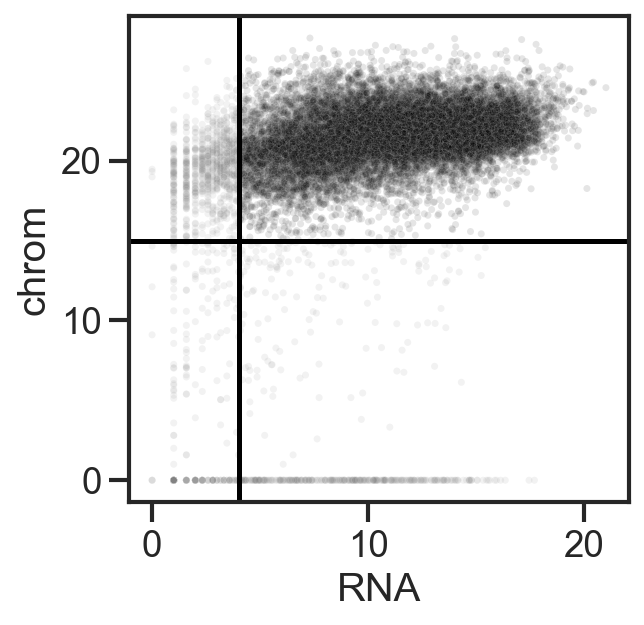

In [15]:
#select genes mappable on at least one chromatin and RNA layer
totalcounts=pd.DataFrame(index=tss_rna.columns, columns=['RNA','K4','K27'])
totalcounts['RNA']=np.log2(tss_rna.sum(axis=0)+1)
totalcounts['K4']=np.log2(tss_k4.sum(axis=0)+1)
totalcounts['K27']=np.log2(tss_k27.sum(axis=0)+1)
totalcounts['chrom']=totalcounts['K4']+totalcounts['K27']
totalcounts['sel']='no'
totalcounts.loc[((totalcounts['RNA']>4)&(totalcounts['chrom']>15)),'sel']='yes'
genes_to_use=totalcounts[totalcounts['sel']=='yes'].index.tolist()

ax=sns.scatterplot(data=totalcounts, x='RNA', y='chrom', hue='sel',s=10, legend=False, palette=['black','grey'], alpha=0.1)
ax.axhline(y=15, color='black')
ax.axvline(x=4, color='black')
plt.show()
#plt.savefig('figures/fig5/gene_selection_recovery_RNA_CHIC.pdf', dpi='figure', format='pdf', bbox_inches='tight')

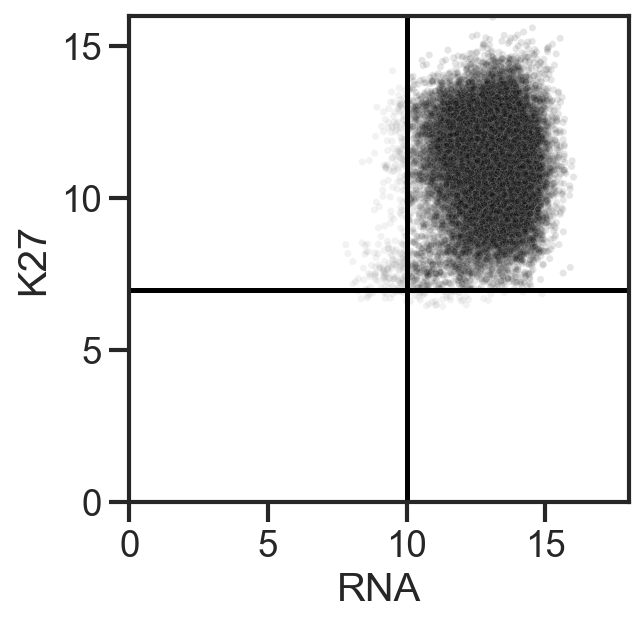

In [16]:
#select cells with enough reads
totalcountsK27=pd.DataFrame(index=tss_k27.index, columns=['RNA','K27'])
totalcountsK27['K27']=np.log2(tss_k27.sum(axis=1)+1)
totalcountsK27['RNA']=np.log2(tss_rna.loc[tss_rna.index.isin(pd.Series(tss_k27.index))].sum(axis=1)+1)
totalcountsK27['sel']='no'
totalcountsK27.loc[((totalcountsK27['RNA']>10)&(totalcountsK27['K27']>7)),'sel']='yes'
K27_cells_to_use=totalcountsK27[totalcountsK27['sel']=='yes'].index.tolist()

ax=sns.scatterplot(data=totalcountsK27, x='RNA', y='K27', hue='sel',s=10, legend=False, palette=['black','grey'], alpha=0.1)
ax.axhline(y=7, color='black')
ax.axvline(x=10, color='black')
ax.set_ylim([0,16])
ax.set_xlim([0,18])
plt.show()
#plt.savefig('figures/fig5/cell_selection_recovery_RNA_K27.pdf', dpi='figure', format='pdf', bbox_inches='tight')

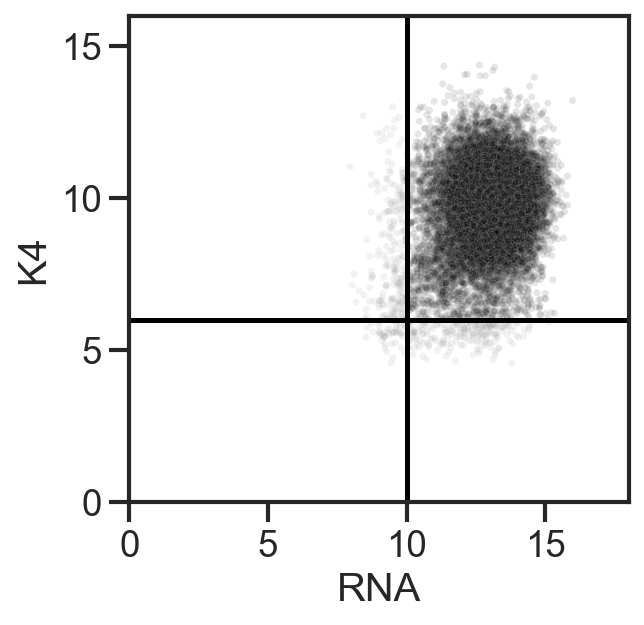

In [17]:
#select cells with enough reads
totalcountsK4=pd.DataFrame(index=tss_k4.index, columns=['RNA','K4'])
totalcountsK4['K4']=np.log2(tss_k4.sum(axis=1)+1)
totalcountsK4['RNA']=np.log2(tss_rna.loc[tss_rna.index.isin(pd.Series(tss_k4.index))].sum(axis=1)+1)

totalcountsK4['sel']='no'
totalcountsK4.loc[((totalcountsK4['RNA']>10)&(totalcountsK4['K4']>6)),'sel']='yes'
K4_cells_to_use=totalcountsK4[totalcountsK4['sel']=='yes'].index.tolist()

ax=sns.scatterplot(data=totalcountsK4, x='RNA', y='K4', hue='sel',s=10, legend=False, palette=['black','grey'], alpha=0.1)
ax.axhline(y=6, color='black')
ax.axvline(x=10, color='black')
ax.set_ylim([0,16])
ax.set_xlim([0,18])
plt.show()
#plt.savefig('figures/fig5/cell_selection_recovery_RNA_K4.pdf', dpi='figure', format='pdf', bbox_inches='tight')

In [18]:
cells_to_use=pd.concat([pd.Series(K4_cells_to_use),pd.Series(K27_cells_to_use)])


In [19]:
#import lineage distribution

lineages=pd.read_csv("input/20240202_9trajectories.csv", sep = ',', header = 0 ,index_col=0)



#add mESCs to linages and remove reprogramming PGCs 
lineages[lineages.index.isin(adata[adata.obs['celltype']=='mESCs'].obs.index)]='mESCs'
lineages=lineages[~lineages.index.isin(adata[adata.obs['celltype']=='Reprogramming PGCs'].obs.index)]



ect1_ct=lineages['ect1_ct'].dropna().index
ect2_ct=lineages['ect2_ct'].dropna().index
ect3_ct=lineages['ect3_ct'].dropna().index
mes1_ct=lineages['mes1_ct'].dropna().index
mes2_ct=lineages['mes2_ct'].dropna().index
mes3_ct=lineages['mes3_ct'].dropna().index
end1_ct=adata.obs[adata.obs['celltype'].isin(['mESCs','Caudal Epiblast','Primitive Streak','Visceral Endoderm','ExE Endoderm'])].index




In [20]:
#create pbs

ect1_PB_counts_50, ect1_PB_meta_50, ect1_cellano =bintable2b(adata[adata.obs['cellname'].isin(ect1_ct)],'ect1',50)
ect2_PB_counts_50, ect2_PB_meta_50, ect2_cellano =bintable2b(adata[adata.obs['cellname'].isin(ect2_ct)],'ect2',50)
ect3_PB_counts_50, ect3_PB_meta_50, ect3_cellano =bintable2b(adata[adata.obs['cellname'].isin(ect3_ct)],'ect3',50)
mes1_PB_counts_50, mes1_PB_meta_50, mes1_cellano =bintable2b(adata[adata.obs['cellname'].isin(mes1_ct)],'mes1',50)
mes2_PB_counts_50, mes2_PB_meta_50, mes2_cellano =bintable2b(adata[adata.obs['cellname'].isin(mes2_ct)],'mes2',50)
mes3_PB_counts_50, mes3_PB_meta_50, mes3_cellano =bintable2b(adata[adata.obs['cellname'].isin(mes3_ct)],'mes3',50)
end1_PB_counts_50, end1_PB_meta_50, end1_cellano =bintable2b(adata[adata.obs['cellname'].isin(end1_ct)],'endo1',50)

all_meta=pd.concat([ect1_PB_meta_50,ect2_PB_meta_50,ect3_PB_meta_50,mes1_PB_meta_50,mes2_PB_meta_50,mes3_PB_meta_50,end1_PB_meta_50])
cellano=pd.concat([ect1_cellano,ect2_cellano,ect3_cellano,mes1_cellano,mes2_cellano,mes3_cellano,end1_cellano]).reset_index()




In [21]:
ect1_sm_l=smooth(ect1_PB_counts_50, stepsizeRNA=20, stepsizeChIC=25,newName='sm_long')
ect2_sm_l=smooth(ect2_PB_counts_50, stepsizeRNA=20, stepsizeChIC=25,newName='sm_long')
ect3_sm_l=smooth(ect3_PB_counts_50, stepsizeRNA=20, stepsizeChIC=25,newName='sm_long')
mes1_sm_l=smooth(mes1_PB_counts_50, stepsizeRNA=20, stepsizeChIC=25,newName='sm_long')
mes2_sm_l=smooth(mes2_PB_counts_50, stepsizeRNA=20, stepsizeChIC=25,newName='sm_long')
mes3_sm_l=smooth(mes3_PB_counts_50, stepsizeRNA=20, stepsizeChIC=25,newName='sm_long')
end1_sm_l=smooth(end1_PB_counts_50, stepsizeRNA=20, stepsizeChIC=25,newName='sm_long')

ect1_sm_s=smooth(ect1_sm_l, stepsizeRNA=10, stepsizeChIC=15,newName='sm_short')
ect2_sm_s=smooth(ect2_sm_l, stepsizeRNA=10, stepsizeChIC=15,newName='sm_short')
ect3_sm_s=smooth(ect3_sm_l, stepsizeRNA=10, stepsizeChIC=15,newName='sm_short')
mes1_sm_s=smooth(mes1_sm_l, stepsizeRNA=10, stepsizeChIC=15,newName='sm_short')
mes2_sm_s=smooth(mes2_sm_l, stepsizeRNA=10, stepsizeChIC=15,newName='sm_short')
mes3_sm_s=smooth(mes3_sm_l, stepsizeRNA=10, stepsizeChIC=15,newName='sm_short')
end1_sm_s=smooth(end1_sm_l, stepsizeRNA=10, stepsizeChIC=15,newName='sm_short')

all_pb_sm_s=pd.concat([ect1_sm_s,ect2_sm_s,ect3_sm_s,mes1_sm_s,mes2_sm_s,mes3_sm_s,end1_sm_s])

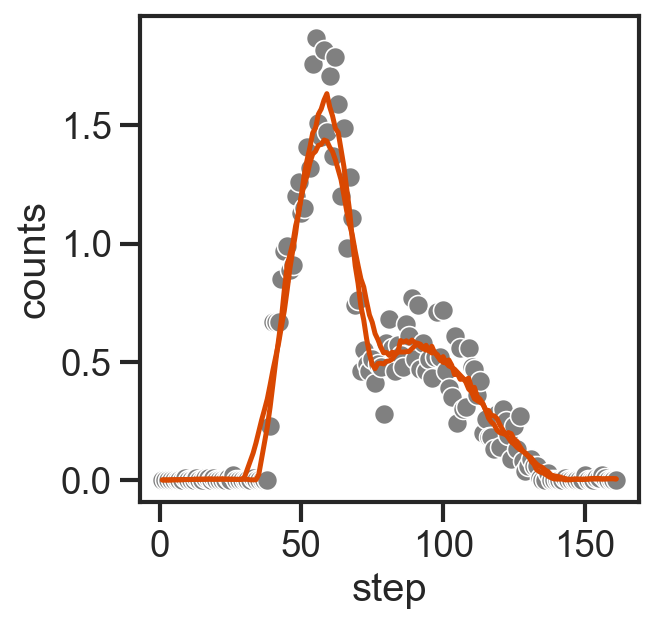

In [22]:
#check smoothing
gene='T'

sns.scatterplot(data=ect1_sm_s[((ect1_sm_s['gene']==gene)&(ect1_sm_s['layer']=='RNA'))], x='step',y='counts', color='Grey')
sns.lineplot(data=ect1_sm_s[((ect1_sm_s['gene']==gene)&(ect1_sm_s['layer']=='RNA'))], x='step',y='sm_long', color=Orange)
sns.lineplot(data=ect1_sm_s[((ect1_sm_s['gene']==gene)&(ect1_sm_s['layer']=='RNA'))], x='step',y='sm_short', color=Orange)
plt.show()

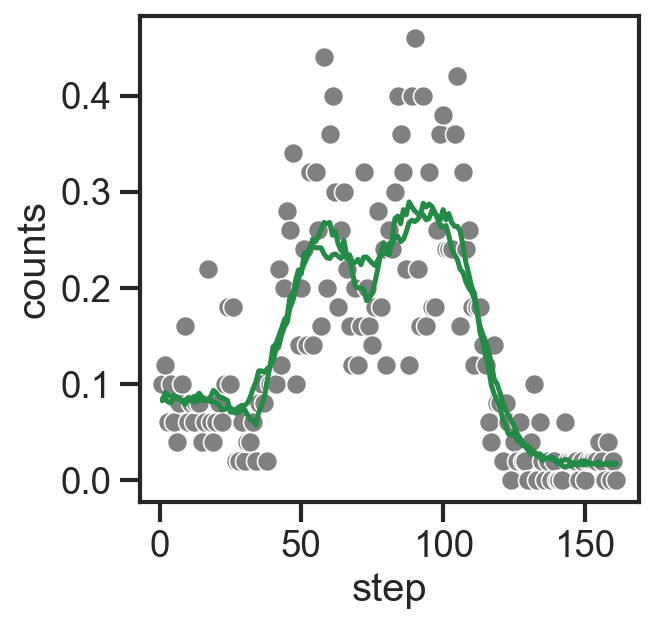

In [23]:
#check smoothing

sns.scatterplot(data=ect1_sm_s[((ect1_sm_s['gene']==gene)&(ect1_sm_s['layer']=='K4'))], x='step',y='counts', color='Grey')
sns.lineplot(data=ect1_sm_s[((ect1_sm_s['gene']==gene)&(ect1_sm_s['layer']=='K4'))], x='step',y='sm_long', color=Green)
sns.lineplot(data=ect1_sm_s[((ect1_sm_s['gene']==gene)&(ect1_sm_s['layer']=='K4'))], x='step',y='sm_short', color=Green)
plt.show()

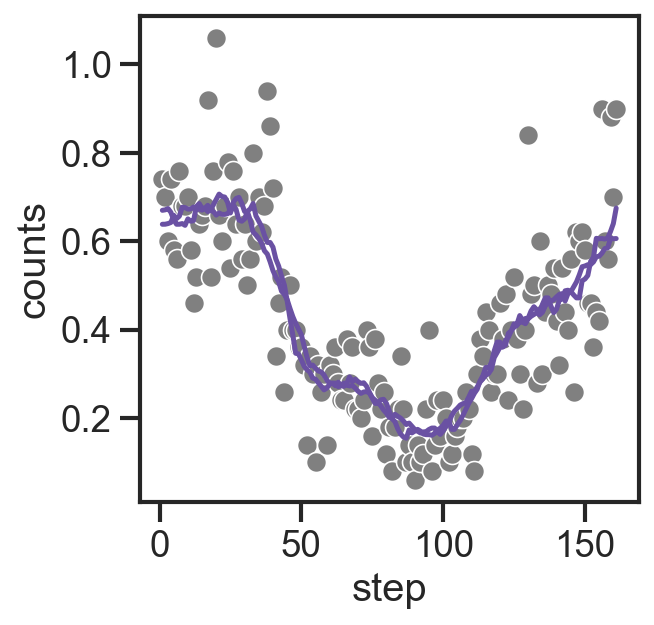

In [24]:
#check smoothing

sns.scatterplot(data=ect1_sm_s[((ect1_sm_s['gene']==gene)&(ect1_sm_s['layer']=='K27'))], x='step',y='counts', color='Grey')
sns.lineplot(data=ect1_sm_s[((ect1_sm_s['gene']==gene)&(ect1_sm_s['layer']=='K27'))], x='step',y='sm_long', color=Purple)
sns.lineplot(data=ect1_sm_s[((ect1_sm_s['gene']==gene)&(ect1_sm_s['layer']=='K27'))], x='step',y='sm_short', color=Purple)
plt.show()

In [25]:
all_meta['step_id']=(all_meta['step'].astype(str))+':'+all_meta['lin']
unique_steps=all_meta.groupby(['UMAP1', 'UMAP2']).first().reset_index(drop = True)['step_id']


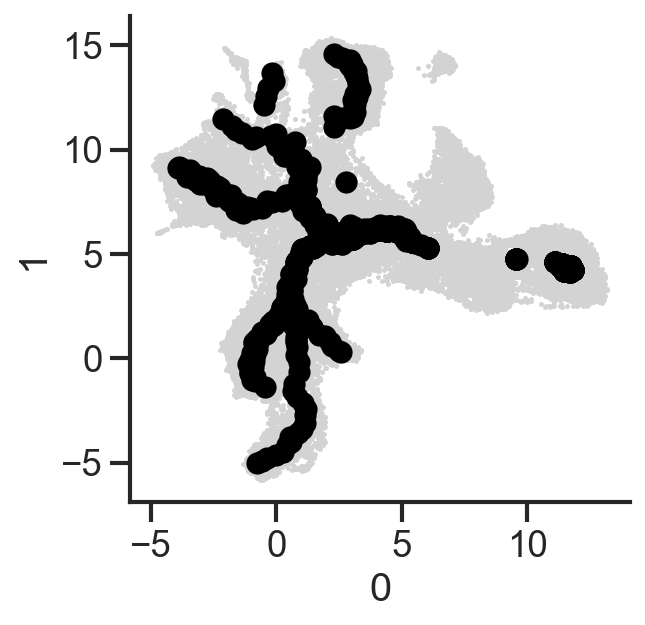

In [26]:
#check pseudobulk distribution

linday_dict=dict(zip(adata.obs['lin_day'].cat.categories, adata.uns['lin_day_colors']))


UMAP_coord_allcells=pd.DataFrame(adata.obsm['X_umap'])

all_meta['RT_nr']=0
all_meta.loc[all_meta['RT']=='mESCs','RT_nr']=0
all_meta.loc[all_meta['RT']=='Gastd3','RT_nr']=1
all_meta.loc[all_meta['RT']=='Gastd4','RT_nr']=2
all_meta.loc[all_meta['RT']=='Gastd5','RT_nr']=3
all_meta.loc[all_meta['RT']=='Gastd6','RT_nr']=4
all_meta.loc[all_meta['RT']=='Gastd7','RT_nr']=5


fig, ax = plt.subplots()
sns.scatterplot(data=UMAP_coord_allcells, x=0, y=1, s=5, color='lightgrey', linewidth=0, ax=ax, alpha=1)
sns.scatterplot(data=all_meta, x='UMAP1', y='UMAP2', s=100, linewidth=0, ax=ax, color='Black', legend=False)

sns.despine()
plt.show()


In [27]:
#create unique step index
all_pb_sm_s['step_id']=(all_pb_sm_s['step']).astype(str)+':'+all_pb_sm_s['lin']
all_pb_sm=all_pb_sm_s

#calculate log2 for plotting and as potential Anova input
all_pb_sm['counts_log2']=np.log2(all_pb_sm['counts']+.01)
all_pb_sm['sm_long_log2']=np.log2(all_pb_sm['sm_long']+.01)
all_pb_sm['sm_short_log2']=np.log2(all_pb_sm['sm_short']+.01)

In [28]:
all_pb_sm2=all_pb_sm.copy()

In [29]:
all_pb_sm2=binarise_unique(all_pb_sm2, unique_steps, 'counts_log2', 'counts_state')
all_pb_sm2=binarise_unique(all_pb_sm2, unique_steps, 'sm_long_log2', 'sm_long_state')
all_pb_sm2=binarise_unique(all_pb_sm2, unique_steps, 'sm_short_log2', 'sm_short_state')


# Header
## subheader
text

In [30]:

#make celltype subsets
celltype_pb_counts, celltype_pb_sub_counts, celltype_pb_meta=bintable_celltype(adata[((adata.obs['celltype_general']!='Epiblast')&(adata.obs['celltype_general']!='PGCs'))], 'celltype', 200)


#calculate log2 as anova input
celltype_pb_sub_counts['counts_log2']=np.log2(celltype_pb_sub_counts['counts']+.01)


#run anova pluri
celltype_RNA_an_plu=anova_celltype(celltype_pb_sub_counts[celltype_pb_sub_counts['celltype'].isin(['mESCs','Caudal Epiblast'])],'RNA')
celltype_K4_an_plu=anova_celltype(celltype_pb_sub_counts[celltype_pb_sub_counts['celltype'].isin(['mESCs','Caudal Epiblast'])],'K4')
celltype_K27_an_plu=anova_celltype(celltype_pb_sub_counts[celltype_pb_sub_counts['celltype'].isin(['mESCs','Caudal Epiblast'])],'K27')


#run anova diff
celltype_RNA_an_dif=anova_celltype(celltype_pb_sub_counts[celltype_pb_sub_counts['celltype']!='mESCs'],'RNA')
celltype_K4_an_dif=anova_celltype(celltype_pb_sub_counts[celltype_pb_sub_counts['celltype']!='mESCs'],'K4')
celltype_K27_an_dif=anova_celltype(celltype_pb_sub_counts[celltype_pb_sub_counts['celltype']!='mESCs'],'K27')


Performing statistics...
Calculating values...
Done!
Performing statistics...
Calculating values...
Done!
Performing statistics...
Calculating values...
Done!
Performing statistics...
Calculating values...
Done!
Performing statistics...
Calculating values...
Done!
Performing statistics...
Calculating values...
Done!


In [31]:
celltype_RNA_an=celltype_RNA_an_plu.copy()
celltype_RNA_an.loc[celltype_RNA_an_plu['p']<celltype_RNA_an_dif['p'],'p']=celltype_RNA_an_dif.loc[celltype_RNA_an_plu['p']<celltype_RNA_an_dif['p'],'p']
celltype_RNA_an.loc[celltype_RNA_an_plu['fold']<celltype_RNA_an_dif['fold'],'fold']=celltype_RNA_an_dif.loc[celltype_RNA_an_plu['fold']<celltype_RNA_an_dif['fold'],'fold']


celltype_K4_an=celltype_K4_an_plu.copy()
celltype_K4_an.loc[celltype_K4_an_plu['p']<celltype_K4_an_dif['p'],'p']=celltype_K4_an_dif.loc[celltype_K4_an_plu['p']<celltype_K4_an_dif['p'],'p']
celltype_K4_an.loc[celltype_K4_an_plu['fold']<celltype_K4_an_dif['fold'],'fold']=celltype_K4_an_dif.loc[celltype_K4_an_plu['fold']<celltype_K4_an_dif['fold'],'fold']


celltype_K27_an=celltype_K27_an_plu.copy()
celltype_K27_an.loc[celltype_K27_an_plu['p']<celltype_K27_an_dif['p'],'p']=celltype_K27_an_dif.loc[celltype_K27_an_plu['p']<celltype_K27_an_dif['p'],'p']
celltype_K27_an.loc[celltype_K27_an_plu['fold']<celltype_K27_an_dif['fold'],'fold']=celltype_K27_an_dif.loc[celltype_K27_an_plu['fold']<celltype_K27_an_dif['fold'],'fold']


In [32]:
celltype_RNA_an.columns=['fold','mean','p_raw','p','state']
celltype_RNA_an['layer']='RNA'

celltype_K4_an.columns=['fold','mean','p_raw','p','state']
celltype_K4_an['layer']='K4'

celltype_K27_an.columns=['fold','mean','p_raw','p','state']
celltype_K27_an['layer']='K27'

celltype_RNA_an['gene']=celltype_RNA_an.index
celltype_RNA_an=celltype_RNA_an[['gene','fold','p','layer']].reset_index(drop=True)
celltype_K4_an['gene']=celltype_K4_an.index
celltype_K4_an=celltype_K4_an[['gene','fold','p','layer']].reset_index(drop=True)
celltype_K27_an['gene']=celltype_K27_an.index
celltype_K27_an=celltype_K27_an[['gene','fold','p','layer']].reset_index(drop=True)

celltype_an=pd.concat([celltype_RNA_an,celltype_K4_an])
celltype_an=celltype_an.reset_index(drop=True)
celltype_an=pd.concat([celltype_an,celltype_K27_an])
celltype_an=celltype_an.reset_index(drop=True)

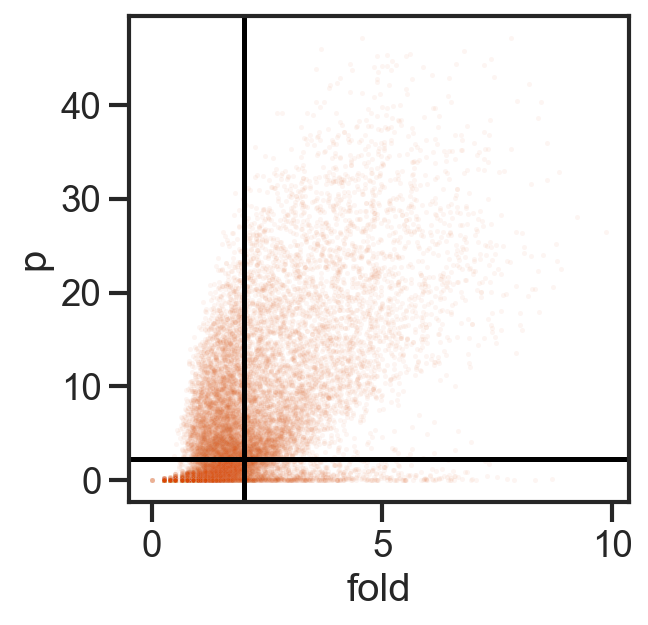

In [33]:
#check if thresholds are correct for data distribution

sns.scatterplot(data=celltype_an[celltype_an['layer']=='RNA'], x='fold', y='p', s=5, alpha=0.05, color=Orange)
plt.axhline(y=2.3, color='Black')
plt.axvline(x=2, color='Black')
plt.show()


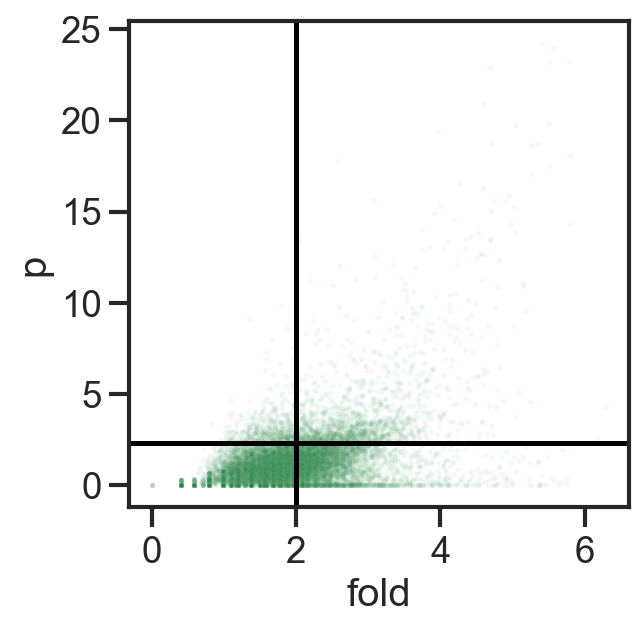

In [34]:
sns.scatterplot(data=celltype_an[celltype_an['layer']=='K4'], x='fold', y='p', s=5, alpha=0.05, color=Green)
plt.axhline(y=2.3, color='Black')
plt.axvline(x=2, color='Black')
plt.show()

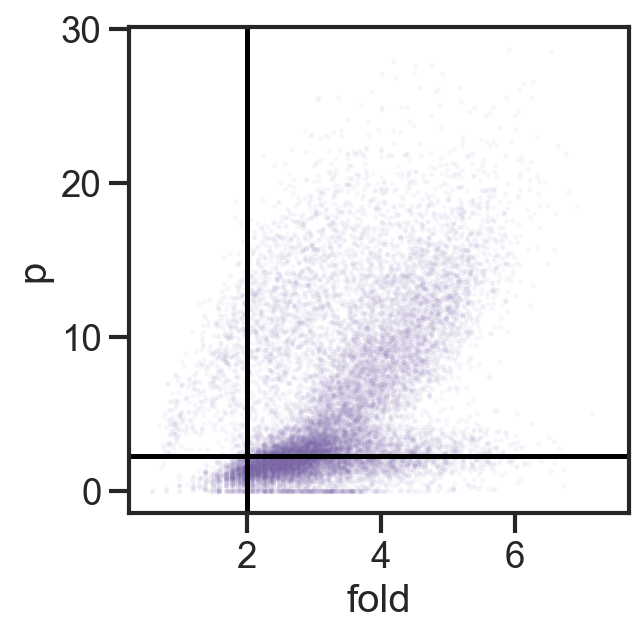

In [35]:
sns.scatterplot(data=celltype_an[celltype_an['layer']=='K27'], x='fold', y='p', s=5, alpha=0.05, color=Purple)
plt.axhline(y=2.3, color='Black')
plt.axvline(x=2, color='Black')
plt.show()

In [36]:
#determine state mean and threshold per gene that will be used for dynmaic genes

RNA_state_mean=pd.DataFrame(all_pb_sm2[all_pb_sm2['layer']=='RNA'].pivot(index='gene', columns='step_id', values='counts_state').mean(axis=1))
RNAmin=(all_pb_sm2[all_pb_sm2['layer']=='RNA'].pivot(index='gene', columns='step_id', values='sm_short').min(axis=1))
RNAmax=(all_pb_sm2[all_pb_sm2['layer']=='RNA'].pivot(index='gene', columns='step_id', values='sm_short').max(axis=1))
RNA_state_mean['th']=RNAmin+((RNAmax-RNAmin)/5)
RNA_state_mean['gene']=RNA_state_mean.index
RNA_state_mean.columns=['state_mean','dyn_threshold','gene']
RNA_state_mean['layer']='RNA'
RNA_state_mean=RNA_state_mean.reset_index(drop=True)

K4_state_mean=pd.DataFrame(all_pb_sm2[all_pb_sm2['layer']=='K4'].pivot(index='gene', columns='step_id', values='counts_state').mean(axis=1))
K4min=(all_pb_sm2[all_pb_sm2['layer']=='K4'].pivot(index='gene', columns='step_id', values='sm_short').min(axis=1))
K4max=(all_pb_sm2[all_pb_sm2['layer']=='K4'].pivot(index='gene', columns='step_id', values='sm_short').max(axis=1))
K4_state_mean['th']=K4min+((K4max-K4min)/5)
K4_state_mean['gene']=K4_state_mean.index
K4_state_mean.columns=['state_mean','dyn_threshold','gene']
K4_state_mean['layer']='K4'
K4_state_mean=K4_state_mean.reset_index(drop=True)

K27_state_mean=pd.DataFrame(all_pb_sm2[all_pb_sm2['layer']=='K27'].pivot(index='gene', columns='step_id', values='counts_state').mean(axis=1))
K27min=(all_pb_sm2[all_pb_sm2['layer']=='K27'].pivot(index='gene', columns='step_id', values='sm_short').min(axis=1))
K27max=(all_pb_sm2[all_pb_sm2['layer']=='K27'].pivot(index='gene', columns='step_id', values='sm_short').max(axis=1))
K27_state_mean['th']=K27min+((K27max-K27min)/5)
K27_state_mean['gene']=K27_state_mean.index
K27_state_mean.columns=['state_mean','dyn_threshold','gene']
K27_state_mean['layer']='K27'
K27_state_mean=K27_state_mean.reset_index(drop=True)




In [37]:

state_mean=pd.concat([RNA_state_mean,K4_state_mean])
state_mean=state_mean.reset_index(drop=True)
state_mean=pd.concat([state_mean,K27_state_mean])
state_mean=state_mean.reset_index(drop=True)

# merge determined values with main file
all_pb_sm2=all_pb_sm2.merge(state_mean, how='left', left_on=['gene','layer'],right_on=['gene','layer'])

#merge annova output with main file
all_pb_sm2=all_pb_sm2.merge(celltype_an, how='left', left_on=['gene','layer'],right_on=['gene','layer'])


In [38]:
all_pb_sn2_norm=all_pb_sm2

In [39]:
all_pb_sn2_norm['counts_state_fix']=np.nan
all_pb_sn2_norm['sm_long_state_fix']=np.nan
all_pb_sn2_norm['sm_short_state_fix']=np.nan

all_pb_sn2_norm['counts_state_dyn']=np.nan
all_pb_sn2_norm['sm_long_state_dyn']=np.nan
all_pb_sn2_norm['sm_short_state_dyn']=np.nan

all_pb_sn2_norm['var']=0
all_pb_sn2_norm.loc[((all_pb_sn2_norm['p']>2.3)&(all_pb_sn2_norm['fold']>=2)&(all_pb_sn2_norm['state_mean']>0)),'var']=1

all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==0)),'counts_state_fix']=round(all_pb_sn2_norm['state_mean'])
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==0)),'sm_long_state_fix']=round(all_pb_sn2_norm['state_mean'])
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==0)),'sm_short_state_fix']=round(all_pb_sn2_norm['state_mean'])

all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==0)),'counts_state_dyn']=round(all_pb_sn2_norm['state_mean'])
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==0)),'sm_long_state_dyn']=round(all_pb_sn2_norm['state_mean'])
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==0)),'sm_short_state_dyn']=round(all_pb_sn2_norm['state_mean'])

#set fixed states
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)),'counts_state_fix']=all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)),'counts_state']
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)),'sm_long_state_fix']=all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)),'sm_long_state']
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)),'sm_short_state_fix']=all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)),'sm_short_state']

#set dyn states
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)&(all_pb_sn2_norm['counts']>all_pb_sn2_norm['dyn_threshold'])),'counts_state_dyn']=1
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)&(all_pb_sn2_norm['sm_long']>all_pb_sn2_norm['dyn_threshold'])),'sm_long_state_dyn']=1
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)&(all_pb_sn2_norm['sm_short']>all_pb_sn2_norm['dyn_threshold'])),'sm_short_state_dyn']=1

all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)&(all_pb_sn2_norm['counts']<=all_pb_sn2_norm['dyn_threshold'])),'counts_state_dyn']=0
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)&(all_pb_sn2_norm['sm_long']<=all_pb_sn2_norm['dyn_threshold'])),'sm_long_state_dyn']=0
all_pb_sn2_norm.loc[((all_pb_sn2_norm['var']==1)&(all_pb_sn2_norm['sm_short']<=all_pb_sn2_norm['dyn_threshold'])),'sm_short_state_dyn']=0

In [40]:
#export final tables
all_pb_sn2_norm.to_csv('output/Count_data_all_thresh.tsv',header=True, index=True, sep="\t")
all_meta.to_csv('output/Metadata.tsv',header=True, index=True, sep="\t")
all_pb_sn2_norm[['gene', 'step', 'layer', 'counts', 'lin', 'sm_short', 'counts_log2', 'sm_short_log2','sm_short_state_fix', 'sm_short_state_dyn']].to_csv('output/Count_data_all_thresh_min.tsv',header=True, index=True, sep="\t")
